In [1]:
!pip install mne scikit-learn sktime matplotlib numpy

Using default location ~/mne_data for EEGBCI...
Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info stru

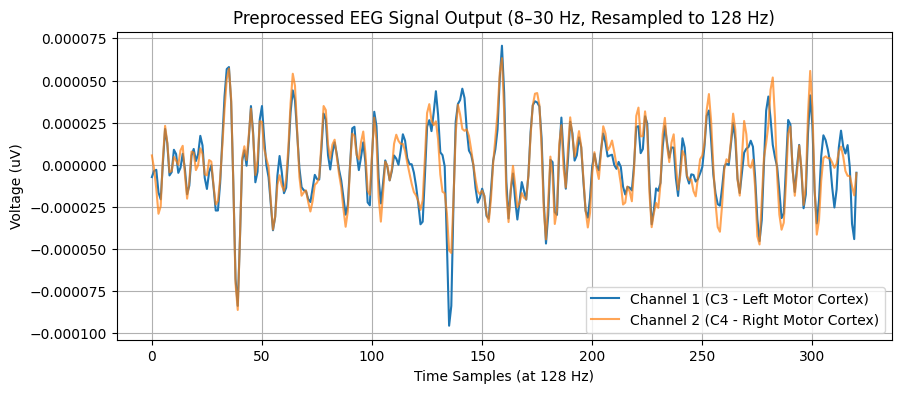

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ==============================================================================
# STEP 1: DATA LOADING (PhysioNet EEG Motor Movement/Imagery Dataset)
# ==============================================================================
# Select Subject 1 for a quick, efficient local demonstration
subject = 1

# Runs 4 & 8: Motor imagery for Left vs. Right hand/fist
# Runs 6 & 10: Motor imagery for Both Hands vs. Both Feet
runs = [4, 8, 6, 10]

print("Downloading small dataset sample (Subject 1)...")
# Download the raw European Data Format (.edf) files directly from PhysioNet
raw_fnames = eegbci.load_data(subject, runs)

# Load raw signals into memory as MNE Raw objects
raw_objs = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]

# Concatenate individual run recordings into one single continuous stream
raw = mne.io.concatenate_raws(raw_objs)

# Standardize electrode channel names to the international 10-20 system (e.g., C3, Cz, C4)
eegbci.standardize(raw)

# ==============================================================================
# STEP 2: SIGNAL PREPROCESSING (Downsampling, Filtering, & Window Epoching)
# ==============================================================================
# A. Downsample the recording frequency to 128 Hz
# - Reduces computational overhead and memory usage
# - Satisfies the Nyquist-Shannon sampling theorem to preserve waves up to 64 Hz
raw.resample(128)

# B. Apply an 8.0 - 30.0 Hz Bandpass Filter
# - Isolates the key motor imagery rhythms: mu (8-14 Hz) and beta (14-30 Hz)
# - Strips out low-frequency baseline drift (<8 Hz) and high-frequency muscle noise (>30 Hz)
raw.filter(8.0, 30.0, fir_design='firwin', skip_by_annotation='edge')

# C. Extract trial markers and slice continuous signals into discrete epochs
events, event_id = mne.events_from_annotations(raw)

# Slice a 2.5-second trial window starting 1.0 second after the visual prompt stimulus
tmin, tmax = 1.0, 3.5

# Group task events into discrete epoch windows
epochs = mne.Epochs(
    raw,
    events,
    event_id={'T1': 2, 'T2': 3},  # Target event markers in PhysioNet
    tmin=tmin,
    tmax=tmax,
    proj=False,
    baseline=None,               # Baseline correction disabled as bandpass filter handles offset
    preload=True
)

# Convert MNE Epochs into a 3D NumPy array for machine learning models
# Array dimensions: (number_of_trials, number_of_electrodes, time_samples_per_trial)
X = epochs.get_data()
y = epochs.events[:, -1]          # Target class labels for each trial

print(f"\n[PREPROCESSING COMPLETE]")
print(f"Total Epochs Processed: {X.shape[0]}")
print(f"Channels (Electrodes): {X.shape[1]}")
print(f"Time Samples per trial: {X.shape[2]} (2.5 seconds * 128 Hz)")

# ==============================================================================
# STEP 3: FEATURE EXTRACTION (MiniRocket) & CLASSIFICATION (Ridge)
# ==============================================================================
# Partition data into 80% Training and 20% Testing sets
# 'stratify=y' ensures equal class balance across both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nExtracting features using MiniRocket...")
# Initialize MiniRocket feature transformer
# Applies 10,000 fixed, non-trainable, dilated convolutional kernels of length 9
# Calculates PPV (Proportion of Positive Values) pooling to flatten time-series into 1D vectors
minirocket = MiniRocketMultivariate(num_kernels=10000, random_state=42)

# Fit kernels on training set and transform 3D trial arrays into 2D feature matrices
X_train_transformed = minirocket.fit_transform(X_train)
X_test_transformed = minirocket.transform(X_test)

# Train a Ridge Regression Classifier
# Uses 10-fold cross-validation (CV) to find the optimal L2 regularization alpha parameter
clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf.fit(X_train_transformed, y_train)

# Evaluate model performance on unseen test data
y_pred = clf.predict(X_test_transformed)
acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy on small sample test set: {acc * 100:.2f}%")

# ==============================================================================
# STEP 4: VISUALIZATION OF PREPROCESSED SIGNALS
# ==============================================================================
plt.figure(figsize=(10, 4))

# Plot time-series voltage wave across Trial 0 for electrode C3 (Left Motor Cortex)
plt.plot(X[0, 0, :], label="Channel 1 (C3 - Left Motor Cortex)")

# Plot time-series voltage wave across Trial 0 for electrode C4 (Right Motor Cortex)
plt.plot(X[0, 1, :], label="Channel 2 (C4 - Right Motor Cortex)", alpha=0.7)

plt.title("Preprocessed EEG Signal Output (8–30 Hz, Resampled to 128 Hz)")
plt.xlabel("Time Samples (at 128 Hz)")
plt.ylabel("Voltage (uV)")
plt.legend()
plt.grid(True)
plt.show()